**importing pandas, matplotlib,numpy**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Mounting .csv file from google drive**

In [2]:
from google.colab import drive
drive.mount("/content/Drive")

Drive already mounted at /content/Drive; to attempt to forcibly remount, call drive.mount("/content/Drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/Drive/MyDrive/dsml/survey_student(in).csv")

**information of the data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Timestamp                                                                                          406 non-null    object 
 1   Your Sex?                                                                                          404 non-null    object 
 2   Your Matric (grade 12) Average/ GPA (in %)                                                         399 non-null    float64
 3   What year were you in last year (2023) ?                                                           333 non-null    object 
 4   What faculty does your degree fall under?                                                          399 non-null    object 

**Mathematical description of data**

In [5]:
df.describe()

,Your Matric (grade 12) Average/ GPA (in %),Your 2023 academic year average/GPA in % (Ignore if you are 2024 1st year student)
count,399.000000,320.000000
mean,77.989724,66.268469
std,7.048618,9.147906
min,34.000000,30.000000
25%,74.000000,60.000000
50%,78.000000,65.000000
75%,83.000000,73.000000
max,99.000000,95.220000


**changing the names of columns**

In [6]:
df.columns = ["timestamp", "gender", "matric_gpa", "study_year", "faculty", "current_gpa", "accommodation", "monthly_allowance", "scholarship", "study_hours", "alcohol_consumption", "classes_missed", "failed_modules", "romantic_relationship", "parent_relationship", "parental_approval", "alcohol_affects_academics"]

In [7]:
df.columns

Index(['timestamp', 'gender', 'matric_gpa', 'study_year', 'faculty',
       'current_gpa', 'accommodation', 'monthly_allowance', 'scholarship',
       'study_hours', 'alcohol_consumption', 'classes_missed',
       'failed_modules', 'romantic_relationship', 'parent_relationship',
       'parental_approval', 'alcohol_affects_academics'],
      dtype='object')

**fetching the year of admission**

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["admission_year"] = df["timestamp"].dt.year
col = df.pop("admission_year")
df.insert(0,"admission_year",col)

/tmp/ipykernel_7124/2051048952.py:1: FutureWarning: Parsed string "2024/03/07 5:12:01 pm EET" included an un-recognized timezone "EET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df["timestamp"] = pd.to_datetime(df["timestamp"])
/tmp/ipykernel_7124/2051048952.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])
/tmp/ipykernel_7124/2051048952.py:1: FutureWarning: Parsed string "2024/03/07 5:12:08 pm EET" included an un-recognized timezone "EET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df["timestamp"] = pd.to

**counting number of null values in each column**

In [9]:
df.isna().sum()

,0
admission_year,0
timestamp,0
gender,2
matric_gpa,7
study_year,73
faculty,7
current_gpa,86
accommodation,23
monthly_allowance,31
scholarship,8


**dropping columns**

In [10]:
df.drop(columns = ["timestamp","alcohol_consumption","romantic_relationship","parent_relationship","parental_approval","alcohol_affects_academics"],inplace = True)

**Filling numeric values**

In [11]:
numeric_columns = df.select_dtypes(include = "number")
numeric_columns.columns

Index(['admission_year', 'matric_gpa', 'current_gpa'], dtype='object')

In [12]:
for col in numeric_columns:
  df[col] = df[col].fillna(df[col].median())

**filling null categorical data**

In [13]:
categorical_columns = df.select_dtypes(include = "object")
print(categorical_columns.columns)
for col in categorical_columns:
  print(df[col].isnull().mean())

Index(['gender', 'study_year', 'faculty', 'accommodation', 'monthly_allowance',
       'scholarship', 'study_hours', 'classes_missed', 'failed_modules'],
      dtype='object')
0.0049261083743842365
0.17980295566502463
0.017241379310344827
0.05665024630541872
0.07635467980295567
0.019704433497536946
0.007389162561576354
0.0049261083743842365
0.007389162561576354


In [14]:
for col in ["gender","accommodation","scholarship"]:
  df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
for col in ["study_year","faculty"]:
  df[col] = df[col].fillna("Unknown")

In [16]:
df.isnull().sum()

,0
admission_year,0
gender,0
matric_gpa,0
study_year,0
faculty,0
current_gpa,0
accommodation,0
monthly_allowance,31
scholarship,0
study_hours,3


In [17]:
df["study_hours"].unique()

array(['8+', '5-Mar', '8-May', '3-Jan', '0', nan], dtype=object)

In [18]:
df["classes_missed"].unique()

array(['8+', '5-Mar', '8-May', '3-Jan', '0', nan], dtype=object)

**mapping the categorical value of hours_studied and classes_missed and monthly_allowance**

In [19]:
hours_map = {
    "3-Jan":2,
    "5-Mar": 4,
    "8-May":7,
    "8+" : 8,
    "0" : 0,
    "1" : 1,
    "2" : 2,
    "4+" : 4,
    "3" : 3,
    "Only weekends":np.nan,
    "np.nan": np.nan
}

for col in ["study_hours","classes_missed","failed_modules"]:
  df[col] = df[col].map(hours_map).astype(float)
  df[col] = df[col].fillna(df[col].median())

In [20]:
allowance_map = {
    "R 4001- R 5000" : 4500,
    "R 5001 - R 6000" : 5500,
    "R 6001 - R 7000" : 6500,
    "R 7001 - R 8000" : 7500,
    "R 8000+" : 8500
}
df["monthly_allowance"] = df["monthly_allowance"].map(allowance_map)
df["monthly_allowance"] = df["monthly_allowance"].fillna(df["monthly_allowance"].median()).astype("float")

**checking how the data looks after data cleaning**

In [21]:
df.sample(5)

,admission_year,gender,matric_gpa,study_year,faculty,current_gpa,accommodation,monthly_allowance,scholarship,study_hours,classes_missed,failed_modules
149,2024,Female,78.0,2nd Year,Arts & Social Sciences,65.0,Private accommodation/ stay with family/friends,5500.0,No,7.0,4.0,2.0
398,2024,Female,74.0,2nd Year,Economic & Management Sciences,60.0,Private accommodation/ stay with family/friends,6500.0,No,7.0,2.0,0.0
404,2024,Male,85.0,Unknown,Economic & Management Sciences,65.0,Private accommodation/ stay with family/friends,4500.0,No,2.0,7.0,4.0
294,2024,Female,94.0,2nd Year,Economic & Management Sciences,67.0,Non-private accommodation ie. Res,4500.0,No,8.0,2.0,0.0
237,2024,Male,84.0,1st Year,Science,92.0,Non-private accommodation ie. Res,5500.0,No,4.0,8.0,0.0


# **Normalization**

**importing label encoder and ohe (using pandas)**

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

**using ohe for gender, faculty and accomodation**

In [23]:
df = pd.get_dummies(df,columns = ["gender","faculty","accommodation"])
bool_cols = df.select_dtypes(include = "bool").columns
df[bool_cols] = df[bool_cols].astype(int)

**using label encoder for admission_year**

In [24]:
df["study_year"] = le.fit_transform(df["study_year"]).astype(int)

**mapping scholarship (yes = 1, no = 0)**

In [25]:
df["scholarship"].isna().sum()

np.int64(0)

In [26]:
df["scholarship"] = df["scholarship"].map({"Yes (NSFAS, etc...)" : 1, "No" : 0})

In [27]:
df.sample(5)

,admission_year,matric_gpa,study_year,current_gpa,monthly_allowance,scholarship,study_hours,classes_missed,failed_modules,gender_Female,...,faculty_Arts & Social Sciences,faculty_Economic & Management Sciences,faculty_Education,faculty_Engineering,faculty_Law,faculty_Medicine and Health Services,faculty_Science,faculty_Unknown,accommodation_Non-private accommodation ie. Res,accommodation_Private accommodation/ stay with family/friends
138,2024,70.0,4,68.0,4500.0,0,2.0,4.0,2.0,0,...,0,0,0,0,0,0,0,0,0,1
324,2024,90.0,2,73.0,5500.0,0,8.0,2.0,0.0,1,...,0,1,0,0,0,0,0,0,0,1
53,2024,84.0,0,74.0,4500.0,0,2.0,2.0,0.0,0,...,0,0,0,0,0,0,1,0,1,0
299,2024,79.0,1,77.0,5500.0,0,2.0,2.0,0.0,1,...,0,1,0,0,0,0,0,0,0,1
18,2024,83.0,5,65.0,5500.0,0,8.0,2.0,0.0,1,...,0,0,0,0,0,1,0,0,0,1


**printing outliers using boxplot for each numeric columns**

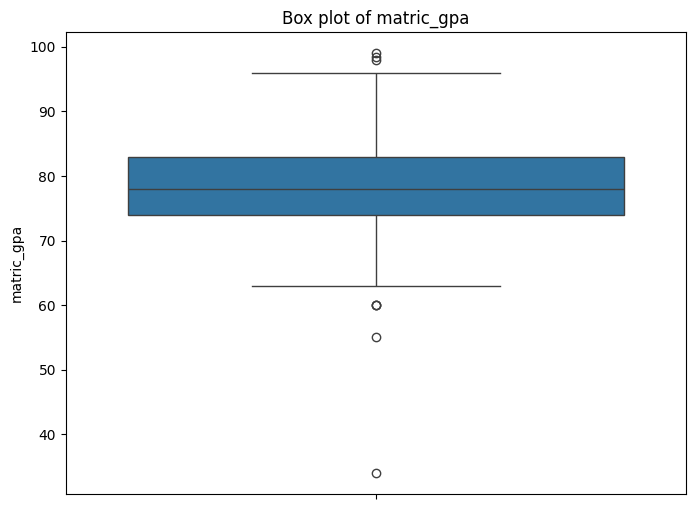

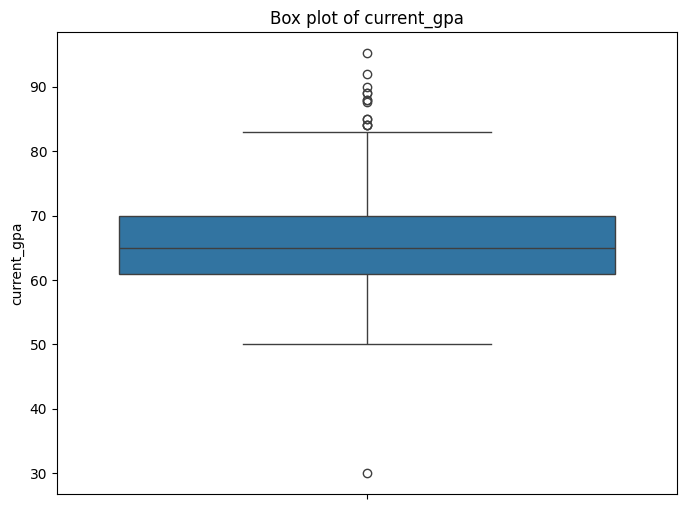

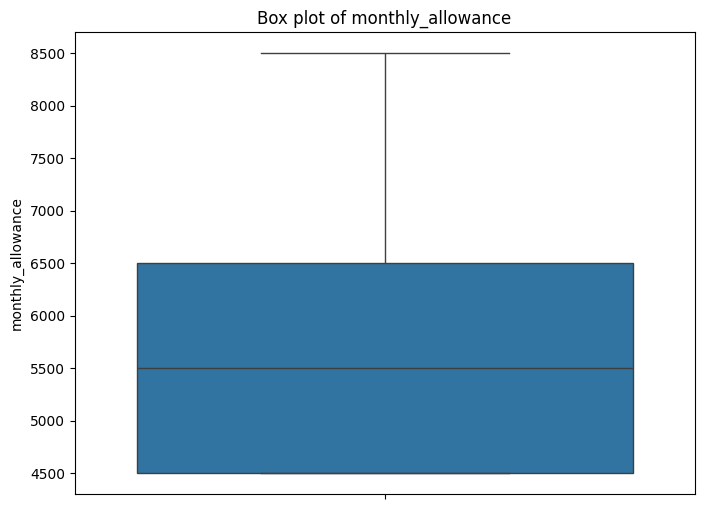

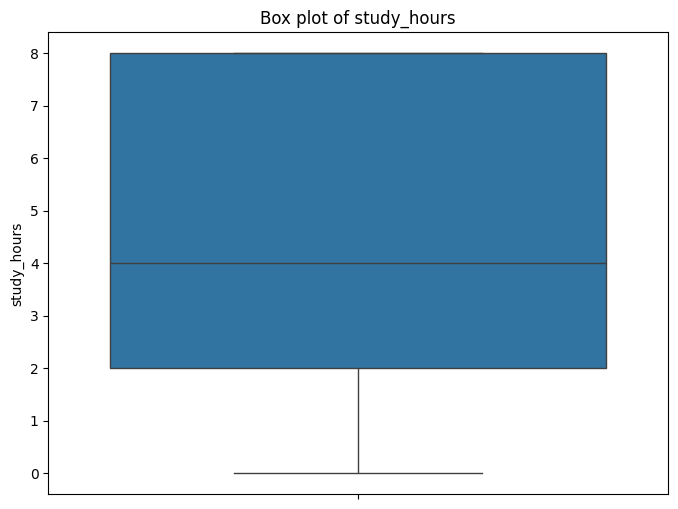

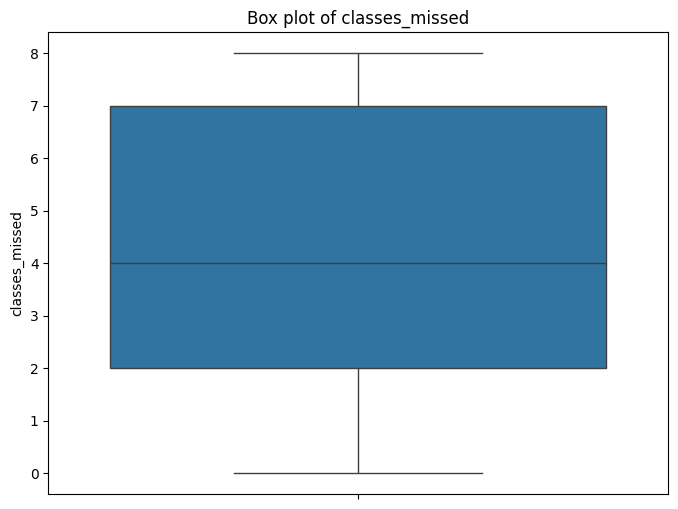

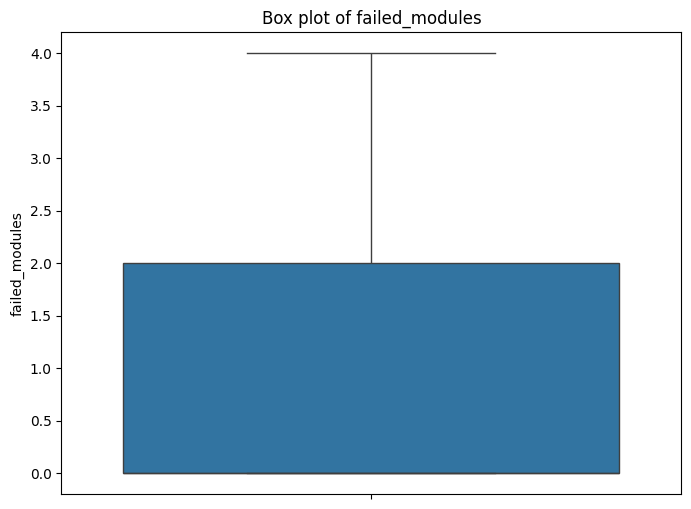

In [35]:
for col in ["matric_gpa","current_gpa","monthly_allowance","study_hours","classes_missed","failed_modules"]:
  plt.figure(figsize = (8,6))
  sns.boxplot(df[col])
  plt.title(f"Box plot of {col}")
  plt.show()

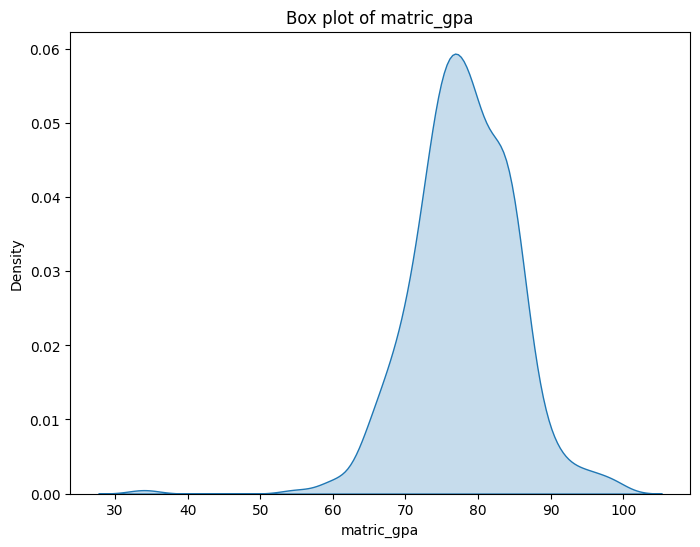

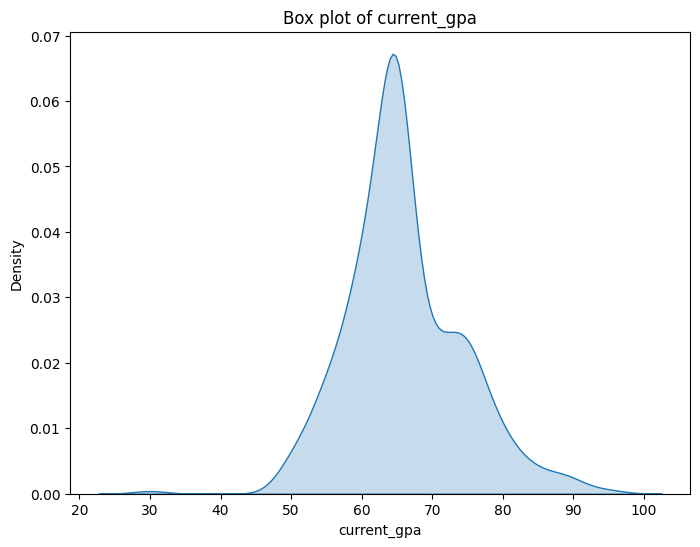

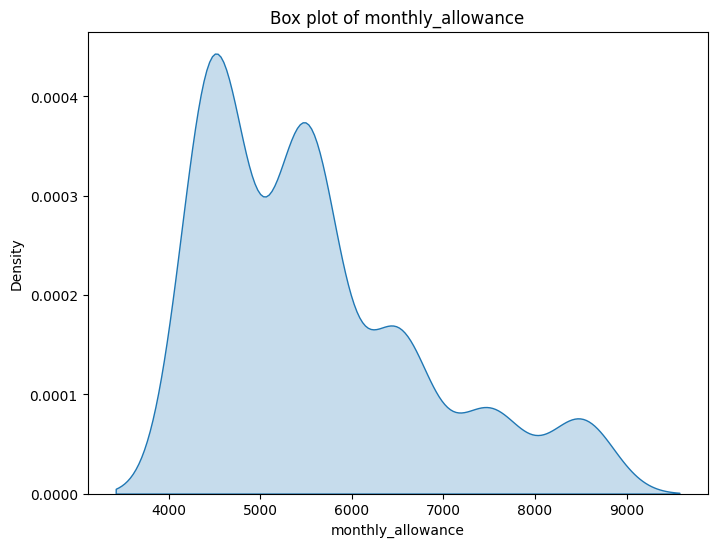

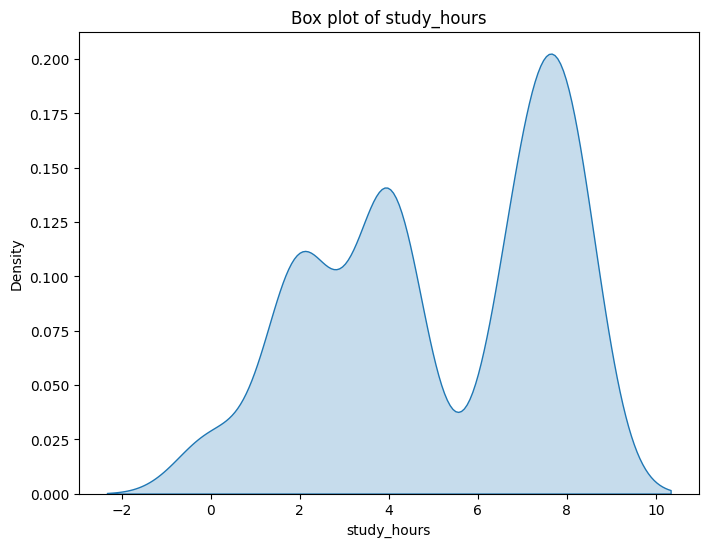

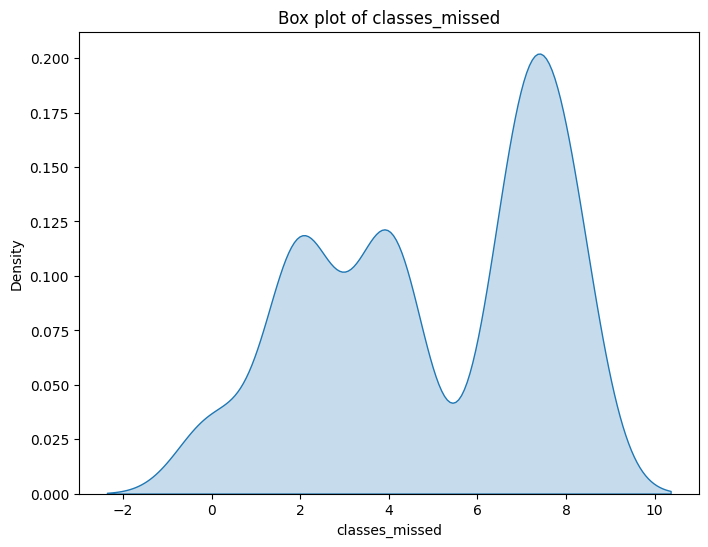

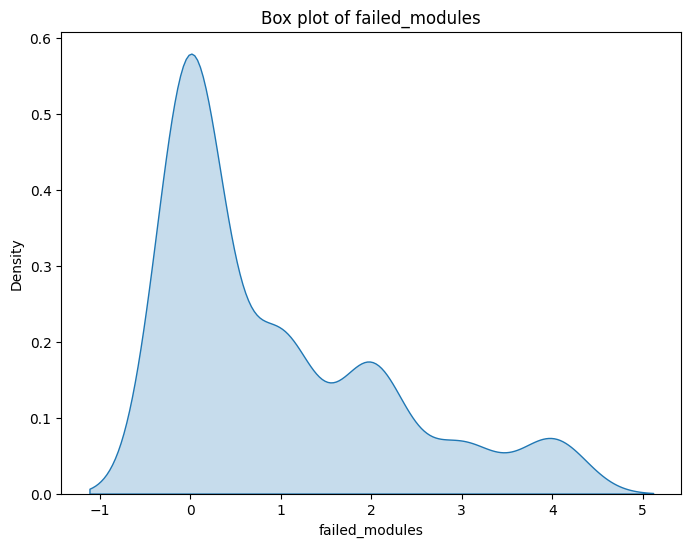

In [36]:
for col in ["matric_gpa","current_gpa","monthly_allowance","study_hours","classes_missed","failed_modules"]:
  plt.figure(figsize = (8,6))
  sns.kdeplot(df[col],fill = True)
  plt.title(f"Box plot of {col}")
  plt.show()

# **Normalizing**

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

**normalizing matric_gpa**

In [39]:
df[["matric_gpa"]] = scaler.fit_transform(df[["matric_gpa"]])

**normalizing current_gpa**

In [40]:
df[["current_gpa"]] = scaler.fit_transform(df[["current_gpa"]])